# LAB 1 for CS4243: Textures and Materials
## Notebook 4 — Personal photos and controlled VLM defect analysis

> **Introduction.** This final notebook combines two open-ended studies. Part I
> develops Texture Passports for your own photographs. Part II evaluates a VLM
> such as ChatGPT on five held-out MVTec defects under three controlled levels
> of information. Preserve inputs, prompts, outputs, and limitations.


# Part I — Personal-photo investigation

## Before looking at predictions

Complete `personal_annotations.csv` first. Obtain two independent selections
of three to five DTD terms per photograph, remove EXIF metadata, and check that
no people, identifying documents, or precise locations are visible.


## Suggested investigation structure

1. Introduce the collection with all relevant information.
2. Apply the frozen material, defect, and DTD systems without adapting them to this new data.
3. Select revealing successes, failures, and intermediate response maps.
4. Test one focused question about illumination, scale, or viewpoint.
5. Produce one Texture Passport per image and explain/reason about the uncertainty.


In [27]:
import sys
from pathlib import Path

import joblib

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
PERSONAL_MANIFEST = ROOT / "manifests" / "personal_annotations.csv"
MODEL_DIR = ROOT / "outputs" / "models"

print("manifest available:", PERSONAL_MANIFEST.exists())
print("model directory available:", MODEL_DIR.exists())

# Notebooks 2 and 3 save self-describing bundles here. Load whichever are
# available, while keeping this open-ended notebook usable before training.
task_ab_path = MODEL_DIR / "task_ab_models.joblib"
task_c_path = MODEL_DIR / "task_c_attribute_model.joblib"
task_ab_bundle = joblib.load(task_ab_path) if task_ab_path.exists() else None
task_c_bundle = joblib.load(task_c_path) if task_c_path.exists() else None

if task_ab_bundle is None or task_c_bundle is None:
    print("Run Notebooks 2 and 3 first to create any missing model bundles.")
else:
    material_model = task_ab_bundle["material_classifier"]
    normal_models = task_ab_bundle["normal_models"]
    attribute_model = task_c_bundle["attribute_classifier"]
    feature_config = task_ab_bundle["feature_config"]
    normality_config = task_ab_bundle["normality_config"]
    attribute_config = task_c_bundle["feature_config"]
    attributes = task_c_bundle["attributes"]
    print("Loaded Task A/B keys:", sorted(task_ab_bundle))
    print("Loaded Task C keys:", sorted(task_c_bundle))

manifest available: False
model directory available: True
Loaded Task A/B keys: ['feature_config', 'image_size', 'material_classifier', 'materials', 'normal_models', 'normality_config', 'validation_selected_threshold']
Loaded Task C keys: ['attribute_classifier', 'attributes', 'feature_config', 'image_size']


## Personal-photo analysis workspace

When Notebooks 2 and 3 have been run, the setup cell exposes `material_model`, `normal_models`, `attribute_model`, their exact feature configurations, the attribute order, and the complete model bundles. Use these frozen objects without refitting on personal images.

Add your own loading, inference, and plotting cells here. Useful visualisations
include a contact sheet grouped by acquisition condition, image/heatmap/mask
triptychs, material confidence versus anomaly score, and human--model DTD-term
overlap. Every figure should support a stated claim.


In [ ]:
# Add your personal-photo exploration here.
# Start small: load one manifest row, run the frozen models, and build one clear figure.

# Part II — Task D: VLM defect classification

This task tests whether a VLM can identify and name surface defects under three
levels of supplied information. The five queries come from held-out MVTec test.
Do not expose the answer key while collecting predictions.


## Experimental conditions

| Level | Information supplied | Question being tested |
|---|---|---|
| **D1 — Generic zero-shot** | Test image and a generic instruction such as “Find any defect in this surface.” | Can the model discover that something is abnormal without domain guidance? |
| **D2 — Named-defect zero-shot** | Test image, material name, and allowed defect names with short verbal definitions; no defect images | Does domain vocabulary help the model recognize and name defects? |
| **D3 — Example-conditioned** | D2 information plus the fixed labelled support set from public validation | Can visual examples transfer a defect concept to new images? |

Use the same VLM, model version, decoding settings, query order, and output
format for all three conditions. Start a fresh conversation for each query and
condition so earlier answers do not leak information.


## 1. Load the five held-out queries

The public query manifest contains paths, material names, and allowed labels.
True labels are stored separately in the staff solution folder.


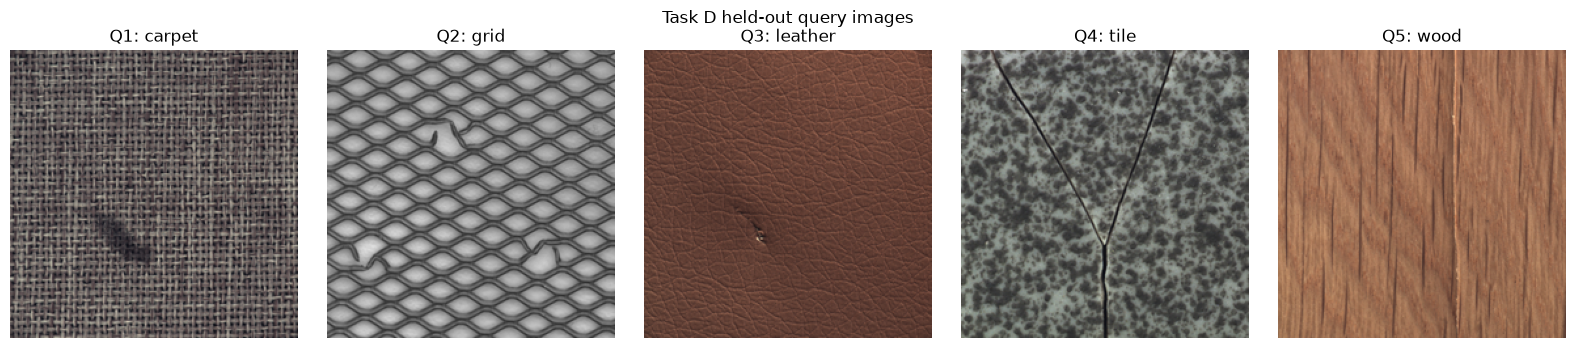

In [ ]:
import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from texturelab.supplied import load_image

MANIFEST_DIR = ROOT / "manifests"

with (MANIFEST_DIR / "task_d_queries.csv").open(newline="", encoding="utf8") as handle:
    queries = list(csv.DictReader(handle))

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
for ax, query in zip(axes, queries):
    path = (MANIFEST_DIR / query["path"]).resolve()
    ax.imshow(load_image(str(path), (220, 220)))
    ax.set_title(f"{query['id']}: {query['material']}")
    ax.axis("off")
fig.suptitle("Task D held-out query images")
fig.tight_layout()
plt.show()

## 2. D1 — generic zero-shot

Attach one query image and use only a generic prompt. Ask for a binary defect
decision, a short defect name if abnormal, confidence from 0 to 100, and one
sentence of visible evidence. Do not mention the material or allowed labels.

Suggested prompt:

> Inspect this surface image. Is anything visibly abnormal? Return JSON with
> `is_defective`, `defect_name`, `confidence`, and `evidence`.


Used prompt : Inspect this surface image. Is anything visibly abnormal? 
Return only valid JSON withis_defective, defect_name, confidence, and evidence.

Model : GPT-5.6-sol

D1 - Results : 


Q1
{"is_defective":true,"defect_name":"localized weave distortion/damaged fibers","confidence":0.98,"evidence":"A clearly visible abnormal dark, irregular patch appears in the lower-left/center region, where the otherwise regular woven pattern is disrupted and fibers appear bunched, displaced, or damaged."}

Q2
{"is_defective":true,"defect_name":"broken mesh strands","confidence":0.99,"evidence":"Multiple clear discontinuities are visible in the repeating mesh pattern, with several strands broken, bent, and displaced around the upper-center, lower-left, and lower-right regions."}

Q3
{"is_defective":true,"defect_name":"puncture/tear","confidence":0.99,"evidence":"A distinct small puncture with a short tear and raised/damaged material is visible slightly left of center, disrupting the otherwise consistent textured surface."}

Q4 
{"is_defective":true,"defect_name":"crack","confidence":0.99,"evidence":"A prominent Y-shaped dark crack is visible through the center of the surface, with three distinct branches disrupting the surrounding material."}

Q5
{"is_defective":true,"defect_name":"split/crack","confidence":0.98,"evidence":"A prominent vertical separation runs nearly the full height slightly right of center, forming an irregular open split that is distinct from the surrounding wood grain."}


## 3. D2 — named-defect zero-shot

Provide the material and its allowed defect names with the supplied short
definitions, but no labelled example images. Require exactly one allowed label
or `good`.


In [11]:
prompt = """
Inspect this surface image and find if there is among the following :
{definition}
Only consider a SINGLE label otherwise set defect name to "good".
Return only valid JSON with is_defective, defect_name, confidence, and evidence.
"""

In [ ]:
import json

PROMPT_TEMPLATE = """
Inspect this surface image and find if there is among the following :
{definition}
Only consider a SINGLE label otherwise set defect name to "good".
Return only valid JSON with is_defective, defect_name, confidence, and evidence.
"""

definitions = json.loads(
    (MANIFEST_DIR / "task_d_definitions.json").read_text(encoding="utf8")
)
prompts = []
for query in queries:
    defs = definitions[query["material"]]
    definition = "\n".join(f"- {name}: {d}" for name, d in defs.items())
    prompts.append(PROMPT_TEMPLATE.format(definition=definition))
    print(f"{query['id']} — {query['material']}")
    print(prompts[-1])

Q1 — carpet

Inspect this surface image and find if there is among the following :
- color: A localized region has an abnormal colour or tone.
- cut: A sharp incision or sliced region interrupts the texture.
- hole: Material is missing in a compact hole-like region.
- metal_contamination: A metallic foreign object lies on the surface.
- thread: A foreign thread lies across the regular texture.
Only consider a SINGLE label otherwise set defect name to "good".
Return only valid JSON with is_defective, defect_name, confidence, and evidence.

Q2 — grid

Inspect this surface image and find if there is among the following :
- bent: The regular grid lines are locally warped or displaced.
- broken: Part of the repeating grid is interrupted or missing.
- glue: A localized glue deposit changes the surface appearance.
- metal_contamination: A metallic foreign object lies on the surface.
- thread: A foreign thread lies across the regular texture.
Only consider a SINGLE label otherwise set defect n

### D2 - Results
Carpet 
{"is_defective":true,"defect_name":"color","confidence":0.96,"evidence":"A localized dark discolored region is visible slightly left of center in the lower-middle portion of the woven surface."}

Grid
{"is_defective":true,"defect_name":"broken","confidence":0.99,"evidence":"Multiple grid strands are visibly interrupted with separated, free-ended segments, especially in the upper-middle, lower-left, and lower-right regions."}

Leather
{"is_defective":true,"defect_name":"poke","confidence":0.97,"evidence":"A small puncture-like opening with localized material disruption is visible slightly left of center."}

Tile
{"is_defective":true,"defect_name":"crack","confidence":0.99,"evidence":"A prominent narrow dark fracture branches from the lower center into two diagonal lines extending toward the upper edges."}

Wood
{"is_defective":true,"defect_name":"scratch","confidence":0.98,"evidence":"A prominent thin vertical abrasion interrupts the wood surface slightly right of center, with exposed lighter material along its edges."}



## 4. D3 — example-conditioned

Provide the same D2 text plus the fixed support images associated with the
query ID in `task_d_support.csv`. Each support image is labelled and comes only
from public validation. Do not add hand-selected examples or test images.

Ask the VLM to compare the query with all examples and return the same JSON
schema used in D1 and D2.


In [47]:
PROMPT_ADDITION = "One of the attached image provides examples for each type of defect, use it to establish the defect type.\n"
prompts_D3 = [p + PROMPT_ADDITION for p in prompts]

In [48]:
for prompt, query in zip(prompts_D3,queries):

    print(f"{query['id']} — {query['material']}")
    print(prompt)

Q1 — carpet

Inspect this surface image and find if there is among the following :
- color: A localized region has an abnormal colour or tone.
- cut: A sharp incision or sliced region interrupts the texture.
- hole: Material is missing in a compact hole-like region.
- metal_contamination: A metallic foreign object lies on the surface.
- thread: A foreign thread lies across the regular texture.
Only consider a SINGLE label otherwise set defect name to "good".
Return only valid JSON with is_defective, defect_name, confidence, and evidence.
One of the attached image provides examples for each type of defect, use it to establish the defect type.

Q2 — grid

Inspect this surface image and find if there is among the following :
- bent: The regular grid lines are locally warped or displaced.
- broken: Part of the repeating grid is interrupted or missing.
- glue: A localized glue deposit changes the surface appearance.
- metal_contamination: A metallic foreign object lies on the surface.
- thr

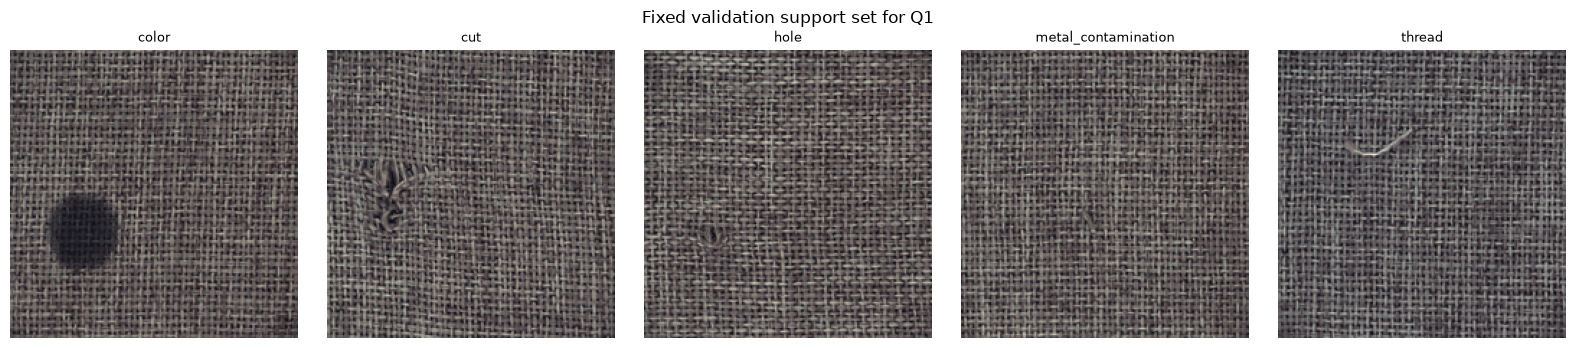

In [32]:
with (MANIFEST_DIR / "task_d_support.csv").open(newline="", encoding="utf8") as handle:
    support = list(csv.DictReader(handle))

# Visualise the fixed support set for the first query.
query_id = queries[0]["id"]
examples = [row for row in support if row["query_id"] == query_id]
fig, axes = plt.subplots(1, len(examples), figsize=(16, 3.5))
for ax, example in zip(axes, examples):
    path = (MANIFEST_DIR / example["path"]).resolve()
    ax.imshow(load_image(str(path), (200, 200)))
    ax.set_title(example["defect_name"], fontsize=9)
    ax.axis("off")
fig.suptitle(f"Fixed validation support set for {query_id}")
fig.tight_layout()
plt.show()

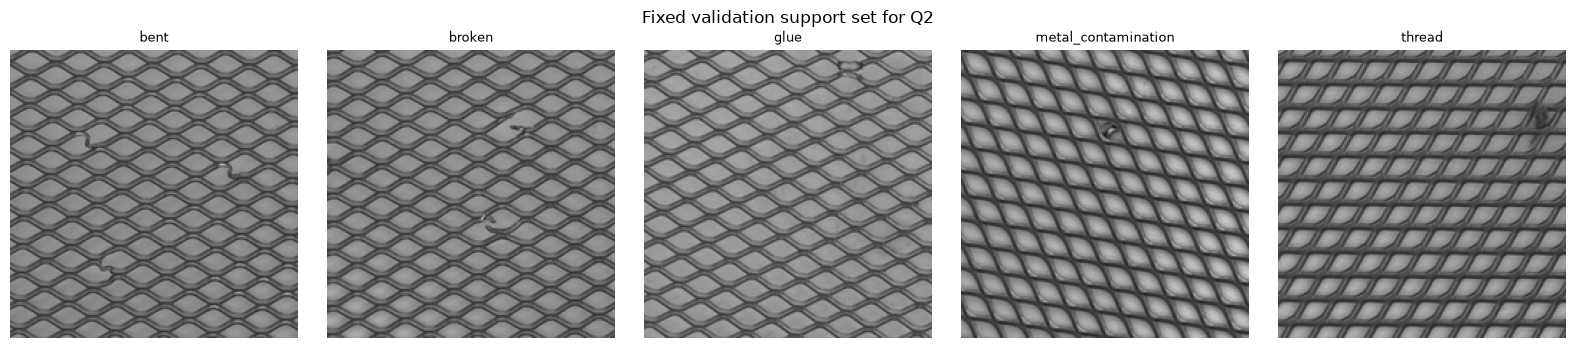

In [33]:
# Visualise the fixed support set for the first query.
query_id = queries[1]["id"]
examples = [row for row in support if row["query_id"] == query_id]
fig, axes = plt.subplots(1, len(examples), figsize=(16, 3.5))
for ax, example in zip(axes, examples):
    path = (MANIFEST_DIR / example["path"]).resolve()
    ax.imshow(load_image(str(path), (200, 200)))
    ax.set_title(example["defect_name"], fontsize=9)
    ax.axis("off")
fig.suptitle(f"Fixed validation support set for {query_id}")
fig.tight_layout()
plt.show()

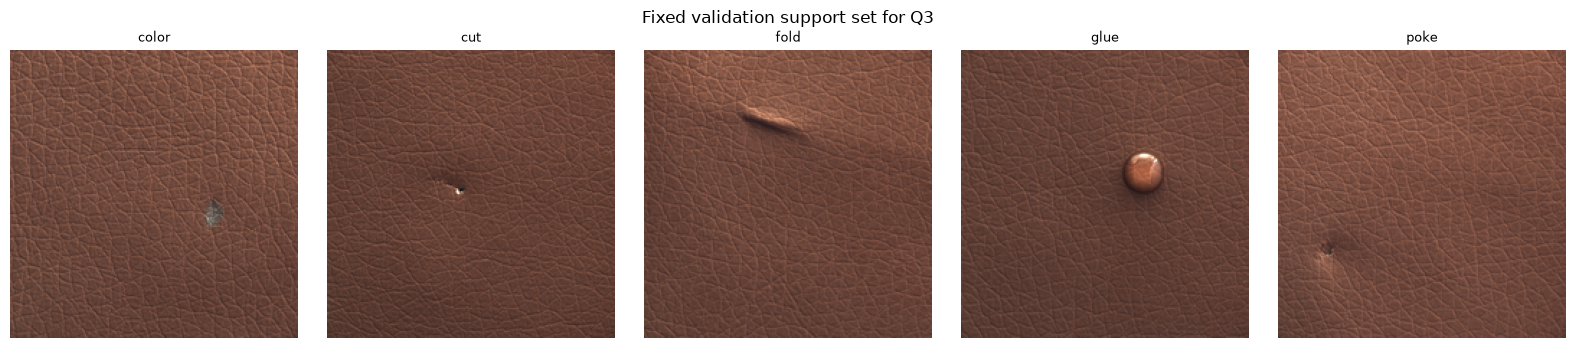

In [34]:
# Visualise the fixed support set for the first query.
query_id = queries[2]["id"]
examples = [row for row in support if row["query_id"] == query_id]
fig, axes = plt.subplots(1, len(examples), figsize=(16, 3.5))
for ax, example in zip(axes, examples):
    path = (MANIFEST_DIR / example["path"]).resolve()
    ax.imshow(load_image(str(path), (200, 200)))
    ax.set_title(example["defect_name"], fontsize=9)
    ax.axis("off")
fig.suptitle(f"Fixed validation support set for {query_id}")
fig.tight_layout()
plt.show()

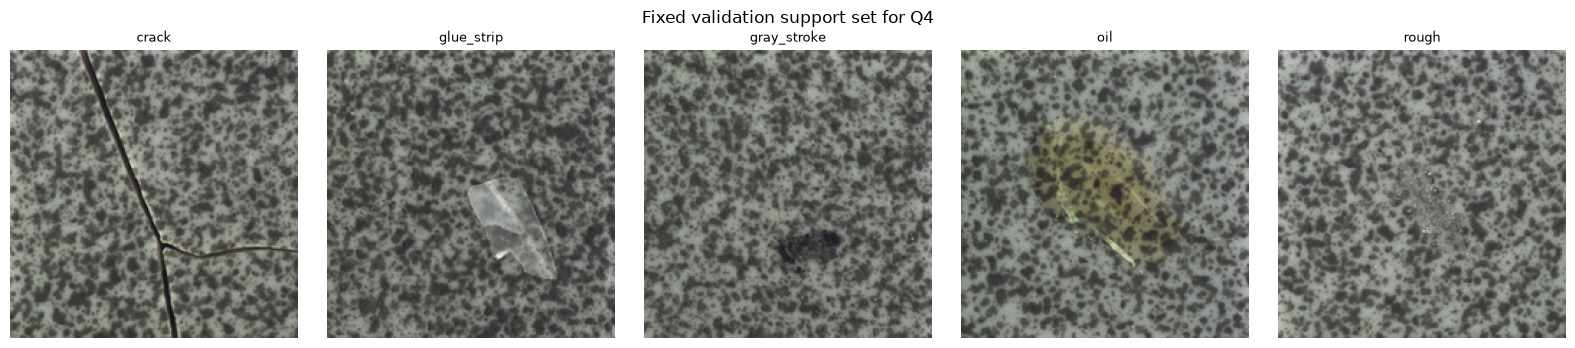

In [35]:
# Visualise the fixed support set for the first query.
query_id = queries[3]["id"]
examples = [row for row in support if row["query_id"] == query_id]
fig, axes = plt.subplots(1, len(examples), figsize=(16, 3.5))
for ax, example in zip(axes, examples):
    path = (MANIFEST_DIR / example["path"]).resolve()
    ax.imshow(load_image(str(path), (200, 200)))
    ax.set_title(example["defect_name"], fontsize=9)
    ax.axis("off")
fig.suptitle(f"Fixed validation support set for {query_id}")
fig.tight_layout()
plt.show()

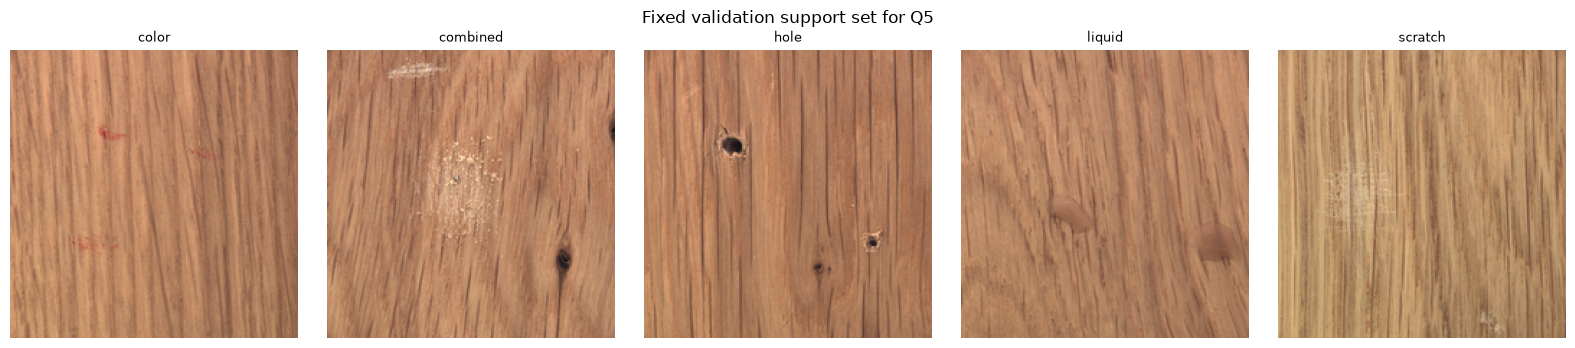

In [36]:
# Visualise the fixed support set for the first query.
query_id = queries[4]["id"]
examples = [row for row in support if row["query_id"] == query_id]
fig, axes = plt.subplots(1, len(examples), figsize=(16, 3.5))
for ax, example in zip(axes, examples):
    path = (MANIFEST_DIR / example["path"]).resolve()
    ax.imshow(load_image(str(path), (200, 200)))
    ax.set_title(example["defect_name"], fontsize=9)
    ax.axis("off")
fig.suptitle(f"Fixed validation support set for {query_id}")
fig.tight_layout()
plt.show()

### D3 - Results

Q1
{"is_defective":true,"defect_name":"color","confidence":0.96,"evidence":"A localized dark-toned patch is visible in the lower-left/central region while the woven texture remains structurally intact, closely matching the provided color-defect example."}

Q2 
{"is_defective":true,"defect_name":"broken","confidence":0.98,"evidence":"Several grid strands are visibly interrupted with separated, free-ended segments, closely matching the provided broken-defect example."}

Q3
{"is_defective":true,"defect_name":"cut","confidence":0.96,"evidence":"A sharp elongated incision with a small opened/damaged endpoint interrupts the leather texture near the lower-left central region, closely matching the provided cut example."}

Q4
{"is_defective":true,"defect_name":"crack","confidence":0.99,"evidence":"Multiple narrow dark fracture-like lines converge near the center and extend across the material surface, closely matching the provided crack example."}

Q5
{"is_defective":false,"defect_name":"good","confidence":0.97,"evidence":"The surface shows normal longitudinal wood grain and a natural seam-like boundary, with no localized abnormal color, compact hole, liquid stain, thin abrasion, or combination of the provided defect types."}

## 5. Record predictions before scoring

Create one row per query and condition with: query ID, condition, predicted
label, defective/not-defective decision, confidence, visible evidence, exact
prompt, model/version, and run date. Preserve the raw conversations or exported
screenshots as evidence. Only after all 15 responses are frozen should the
answer key be used to calculate accuracy.


In [51]:
# [AI-CODE]
import csv
import json

MODEL_VERSION = "GPT-5.6-sol"
RUN_DATE = "2026-10-04"  

D1_PROMPT = (
    "Inspect this surface image. Is anything visibly abnormal? \n"
    "Return only valid JSON withis_defective, defect_name, confidence, and evidence."
)

# Raw VLM outputs, in query order (Q1..Q5), copied verbatim from the cells above.
raw_responses = {
    "D1": [
        '{"is_defective":true,"defect_name":"localized weave distortion/damaged fibers","confidence":0.98,"evidence":"A clearly visible abnormal dark, irregular patch appears in the lower-left/center region, where the otherwise regular woven pattern is disrupted and fibers appear bunched, displaced, or damaged."}',
        '{"is_defective":true,"defect_name":"broken mesh strands","confidence":0.99,"evidence":"Multiple clear discontinuities are visible in the repeating mesh pattern, with several strands broken, bent, and displaced around the upper-center, lower-left, and lower-right regions."}',
        '{"is_defective":true,"defect_name":"puncture/tear","confidence":0.99,"evidence":"A distinct small puncture with a short tear and raised/damaged material is visible slightly left of center, disrupting the otherwise consistent textured surface."}',
        '{"is_defective":true,"defect_name":"crack","confidence":0.99,"evidence":"A prominent Y-shaped dark crack is visible through the center of the surface, with three distinct branches disrupting the surrounding material."}',
        '{"is_defective":true,"defect_name":"split/crack","confidence":0.98,"evidence":"A prominent vertical separation runs nearly the full height slightly right of center, forming an irregular open split that is distinct from the surrounding wood grain."}',
    ],
    "D2": [
        '{"is_defective":true,"defect_name":"color","confidence":0.96,"evidence":"A localized dark discolored region is visible slightly left of center in the lower-middle portion of the woven surface."}',
        '{"is_defective":true,"defect_name":"broken","confidence":0.99,"evidence":"Multiple grid strands are visibly interrupted with separated, free-ended segments, especially in the upper-middle, lower-left, and lower-right regions."}',
        '{"is_defective":true,"defect_name":"poke","confidence":0.97,"evidence":"A small puncture-like opening with localized material disruption is visible slightly left of center."}',
        '{"is_defective":true,"defect_name":"crack","confidence":0.99,"evidence":"A prominent narrow dark fracture branches from the lower center into two diagonal lines extending toward the upper edges."}',
        '{"is_defective":true,"defect_name":"scratch","confidence":0.98,"evidence":"A prominent thin vertical abrasion interrupts the wood surface slightly right of center, with exposed lighter material along its edges."}',
    ],
    "D3": [
        '{"is_defective":true,"defect_name":"color","confidence":0.96,"evidence":"A localized dark-toned patch is visible in the lower-left/central region while the woven texture remains structurally intact, closely matching the provided color-defect example."}',
        '{"is_defective":true,"defect_name":"broken","confidence":0.98,"evidence":"Several grid strands are visibly interrupted with separated, free-ended segments, closely matching the provided broken-defect example."}',
        '{"is_defective":true,"defect_name":"cut","confidence":0.96,"evidence":"A sharp elongated incision with a small opened/damaged endpoint interrupts the leather texture near the lower-left central region, closely matching the provided cut example."}',
        '{"is_defective":true,"defect_name":"crack","confidence":0.99,"evidence":"Multiple narrow dark fracture-like lines converge near the center and extend across the material surface, closely matching the provided crack example."}',
        '{"is_defective":false,"defect_name":"good","confidence":0.97,"evidence":"The surface shows normal longitudinal wood grain and a natural seam-like boundary, with no localized abnormal color, compact hole, liquid stain, thin abrasion, or combination of the provided defect types."}',
    ],
}

condition_prompts = {
    "D1": [D1_PROMPT] * len(queries),
    "D2": prompts,
    "D3": prompts_D3,
}

allowed = {q["id"]: set(q["allowed_defects"].split(";")) | {"good"} for q in queries}

predictions = []
for condition, responses in raw_responses.items():
    for query, prompt, raw in zip(queries, condition_prompts[condition], responses):
        parsed = json.loads(raw) if raw else {}
        label = parsed.get("defect_name")
        predictions.append({
            "query_id": query["id"],
            "material": query["material"],
            "condition": condition,
            "predicted_label": label,
            "is_defective": parsed.get("is_defective"),
            "confidence": parsed.get("confidence"),
            "evidence": parsed.get("evidence"),
            # D1 has no allowed vocabulary, so the check only applies to D2/D3.
            "in_vocabulary": None if condition == "D1" or label is None else label in allowed[query["id"]],
            "prompt": prompt.strip(),
            "model_version": MODEL_VERSION,
            "run_date": RUN_DATE,
            "raw_response": raw,
        })

OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
with (OUT_DIR / "task_d_predictions.csv").open("w", newline="", encoding="utf8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(predictions[0]))
    writer.writeheader()
    writer.writerows(predictions)

# Compact summary (prompts, evidence and raw responses are in the CSV).
print(f"{'query':<6}{'cond':<6}{'defective':<11}{'conf':<6}{'in_vocab':<10}predicted_label")
for row in predictions:
    print(f"{row['query_id']:<6}{row['condition']:<6}{str(row['is_defective']):<11}"
          f"{str(row['confidence']):<6}{str(row['in_vocabulary']):<10}{row['predicted_label']}")


query cond  defective  conf  in_vocab  predicted_label
Q1    D1    True       0.98  None      localized weave distortion/damaged fibers
Q2    D1    True       0.99  None      broken mesh strands
Q3    D1    True       0.99  None      puncture/tear
Q4    D1    True       0.99  None      crack
Q5    D1    True       0.98  None      split/crack
Q1    D2    True       0.96  True      color
Q2    D2    True       0.99  True      broken
Q3    D2    True       0.97  True      poke
Q4    D2    True       0.99  True      crack
Q5    D2    True       0.98  True      scratch
Q1    D3    True       0.96  True      color
Q2    D3    True       0.98  True      broken
Q3    D3    True       0.96  True      cut
Q4    D3    True       0.99  True      crack
Q5    D3    False      0.97  True      good


## Analysis ideas

- Compare D1 anomaly discovery with D2/D3 exact-label accuracy.
- Count answers that violate the allowed vocabulary.
- Plot confidence for correct and incorrect predictions by condition.
- Identify queries where definitions help but examples do not, and vice versa.
- Discuss prompt sensitivity, model updates, nondeterminism, and possible prior
  exposure to the public MVTec dataset.
- Do not claim that five images establish general VLM superiority; this is a
  controlled qualitative probe.
